# Snorkel: Muchas LFs → Label Model supera a Majority Vote

En la demo original con 13 LFs simples, MV y LM daban resultados similares.
Acá agregamos **32 LFs de calidad heterogénea** — alta precisión, correlacionadas y ruidosas —
para demostrar cuándo el Label Model realmente brilla.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from snorkel.labeling import labeling_function, PandasLFApplier, LFAnalysis
from snorkel.labeling.model import LabelModel, MajorityLabelVoter
from snorkel.labeling import filter_unlabeled_dataframe
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix, precision_recall_fscore_support

sns.set_theme(style="whitegrid", context="notebook", palette="deep")
plt.rcParams['figure.dpi'] = 100
np.random.seed(42)
print("Setup completo")

Setup completo


In [2]:
df = pd.read_csv('reviews_productos.csv')
df = df.dropna(subset=['user_review']).reset_index(drop=True)

ABSTAIN = -1; NEGATIVO = 0; NEUTRO = 1; POSITIVO = 2
LABEL_NAMES = ['Negativo', 'Neutro', 'Positivo']

df['y_true'] = df['stars'].apply(lambda s: NEGATIVO if s<=2 else (NEUTRO if s==3 else POSITIVO))
df['t'] = df['user_review'].str.lower()
df['wc'] = df['user_review'].str.split().str.len()
print(f"Dataset: {len(df):,} reviews")

Dataset: 29,611 reviews


---
# 32 Labeling Functions

| Grupo | Cant | Estrategia |
|-------|------|-----------|
| Negativo (alta precisión) | 5 | Keywords fuertes, pocos FP |
| Negativo (overlapping) | 5 | Se solapan con las anteriores |
| Positivo (alta precisión) | 4 | Keywords fuertes |
| Positivo (overlapping) | 8 | Correlacionadas, redundantes |
| Neutro (conflicto) | 10 | Conflictan con POS/NEG en casos ambiguos |

In [3]:
# ═══ NEGATIVO (10 LFs) ═══
@labeling_function()
def n_harsh(x): return NEGATIVO if any(k in x.t for k in ['horrible','pésimo','pesimo','asqueroso','incomible','inaceptable']) else ABSTAIN
@labeling_function()
def n_spoiled(x): return NEGATIVO if any(k in x.t for k in ['podrido','podrida','vencido','vencida','estropeado','estropeada']) else ABSTAIN
@labeling_function()
def n_delivery(x): return NEGATIVO if any(k in x.t for k in ['no llegó','no llego','nunca llegó','llegó mal','llego mal']) else ABSTAIN
@labeling_function()
def n_quality(x): return NEGATIVO if any(k in x.t for k in ['mal estado','mala calidad','pésima calidad','no sirve']) else ABSTAIN
@labeling_function()
def n_appearance(x): return NEGATIVO if any(k in x.t for k in ['feo','fea','sucio','sucia','roto','rota']) else ABSTAIN
@labeling_function()
def n_smell(x): return NEGATIVO if any(k in x.t for k in ['olor feo','mal olor','olor raro','huele mal']) else ABSTAIN
@labeling_function()
def n_negation(x): return NEGATIVO if any(k in x.t for k in ['no es bueno','no está bueno','no sirve','no funciona']) else ABSTAIN
@labeling_function()
def n_disappointment(x): return NEGATIVO if any(k in x.t for k in ['decepcionante','decepcionado','decepcionada','esperaba más']) else ABSTAIN
@labeling_function()
def n_damage(x): return NEGATIVO if any(k in x.t for k in ['dañado','dañada','aplastado','aplastada','agrietado']) else ABSTAIN
@labeling_function()
def n_bugs(x): return NEGATIVO if any(k in x.t for k in ['bicho','gusano','insecto','larva','mosca']) else ABSTAIN
print("10 LFs negativas")

10 LFs negativas


In [4]:
# ═══ POSITIVO (12 LFs) ═══
@labeling_function()
def p_excellent(x): return POSITIVO if any(k in x.t for k in ['excelente','perfecto','perfecta','espectacular','impecable']) else ABSTAIN
@labeling_function()
def p_delicious(x): return POSITIVO if any(k in x.t for k in ['delicioso','deliciosa','riquísimo','riquisimo','buenísimo','buenisimo']) else ABSTAIN
@labeling_function()
def p_recommend(x): return POSITIVO if any(k in x.t for k in ['recomiendo','recomendable','lo volvería','compraría de nuevo']) else ABSTAIN
@labeling_function()
def p_loved(x): return POSITIVO if any(k in x.t for k in ['me encantó','me encanto','divino','divina','me fascinó']) else ABSTAIN
@labeling_function()
def p_very_good(x): return POSITIVO if any(k in x.t for k in ['muy bueno','muy buena','muy rico','muy rica','muy fresco','muy fresca']) else ABSTAIN
@labeling_function()
def p_super(x): return POSITIVO if any(k in x.t for k in ['super bueno','súper bueno','super rico','súper rico','genial']) else ABSTAIN
@labeling_function()
def p_all_ok(x): return POSITIVO if any(k in x.t for k in ['todo ok','todo bien','todo perfecto','todo excelente']) else ABSTAIN
@labeling_function()
def p_good_state(x): return POSITIVO if any(k in x.t for k in ['buen estado','buena calidad','buen producto']) else ABSTAIN
@labeling_function()
def p_arrived_ok(x): return POSITIVO if any(k in x.t for k in ['llegó bien','llego bien','llegó perfecto','llegaron bien']) else ABSTAIN
@labeling_function()
def p_fresh(x):
    if any(w in x.t for w in ['fresco','fresca','frescos','frescas','frescura']):
        if 'no ' not in x.t[:max(0,x.t.find('fresc'))]: return POSITIVO
    return ABSTAIN
@labeling_function()
def p_exclamation_pos(x):
    if '!' in x.user_review:
        if any(k in x.t for k in ['bueno','buena','rico','rica','mejor','mejores','excelente']): return POSITIVO
    return ABSTAIN
@labeling_function()
def p_short_positive(x):
    if x.wc <= 2: return POSITIVO if any(w in x.t for w in ['excelente','perfecto','perfecta','espectacular','impecable','hermoso','divino']) else ABSTAIN
    return ABSTAIN
print("12 LFs positivas")

12 LFs positivas


In [5]:
# ═══ NEUTRO (10 LFs) ═══
@labeling_function()
def m_contrast(x): return NEUTRO if (any(k in x.t for k in ['bueno','buena','rico','rica','bien']) and any(k in x.t for k in ['pero','aunque','sin embargo'])) else ABSTAIN
@labeling_function()
def m_lukewarm(x): return NEUTRO if any(k in x.t for k in ['un poco','más o menos','mas o menos','no tan','medio ']) else ABSTAIN
@labeling_function()
def m_acceptable(x): return NEUTRO if any(k in x.t for k in ['aceptable','pasable','cumple','zafa','está bien','esta bien']) else ABSTAIN
@labeling_function()
def m_regular(x): return NEUTRO if any(k in x.t for k in ['regular','ni muy','ni tan','podría ser mejor']) else ABSTAIN
@labeling_function()
def m_mixed(x):
    pos = sum(1 for k in ['bueno','buena','rico','bien','ok'] if k in x.t)
    neg = sum(1 for k in ['malo','mala','feo','fea','pero'] if k in x.t)
    return NEUTRO if (pos > 0 and neg > 0) else ABSTAIN
@labeling_function()
def m_price(x):
    if any(k in x.t for k in ['caro','cara','precio','costoso','promo']) and x.wc > 2:
        if not any(k in x.t for k in ['excelente','horrible','perfecto','pésimo']): return NEUTRO
    return ABSTAIN
@labeling_function()
def m_size(x):
    if any(k in x.t for k in ['pequeño','pequeña','chico','chica','grande']):
        if not any(k in x.t for k in ['muy','super','horrible','excelente']): return NEUTRO
    return ABSTAIN
@labeling_function()
def m_normal(x): return NEUTRO if 'normal' in x.t and x.wc <= 5 else ABSTAIN
@labeling_function()
def m_so_so(x): return NEUTRO if any(k in x.t for k in ['no es malo','no está mal','no esta mal','podría mejorar']) else ABSTAIN
@labeling_function()
def m_quantity(x): return NEUTRO if any(k in x.t for k in ['poco','poca','menos','mucho','mucha']) and x.wc <= 4 else ABSTAIN
print("10 LFs neutras")

lfs = [n_harsh,n_spoiled,n_delivery,n_quality,n_appearance,n_smell,n_negation,n_disappointment,n_damage,n_bugs,
       p_excellent,p_delicious,p_recommend,p_loved,p_very_good,p_super,p_all_ok,p_good_state,p_arrived_ok,p_fresh,p_exclamation_pos,p_short_positive,
       m_contrast,m_lukewarm,m_acceptable,m_regular,m_mixed,m_price,m_size,m_normal,m_so_so,m_quantity]
print(f"\nTotal: {len(lfs)} LFs")

10 LFs neutras

Total: 32 LFs


---
# Aplicar LFs y entrenar modelos

In [6]:
idx = np.random.permutation(len(df))
split = int(0.8 * len(df))
df_train = df.iloc[idx[:split]].reset_index(drop=True)
df_test = df.iloc[idx[split:]].reset_index(drop=True)

applier = PandasLFApplier(lfs=lfs)
print("Aplicando LFs...")
L_train = applier.apply(df=df_train)
L_test = applier.apply(df=df_test)

lf_names = [lf.name for lf in lfs]
print(f"Train: {len(df_train):,} | Test: {len(df_test):,}")
print(f"Cobertura: {(L_train != ABSTAIN).any(axis=1).mean():.1%}")

Aplicando LFs...


  0%|                                                 | 0/23688 [00:00<?, ?it/s]

  1%|▍                                    | 269/23688 [00:00<00:08, 2686.19it/s]

  2%|▊                                    | 544/23688 [00:00<00:08, 2723.56it/s]

  3%|█▎                                   | 817/23688 [00:00<00:08, 2621.47it/s]

...

 89%|████████████████████████████████▊    | 5254/5923 [00:01<00:00, 2768.92it/s]

 93%|██████████████████████████████████▌  | 5531/5923 [00:02<00:00, 2759.54it/s]

 98%|████████████████████████████████████▎| 5807/5923 [00:02<00:00, 2758.53it/s]

100%|█████████████████████████████████████| 5923/5923 [00:02<00:00, 2736.96it/s]

Train: 23,688 | Test: 5,923
Cobertura: 40.5%


In [7]:
# Majority Vote y Label Model (generativos)
mv = MajorityLabelVoter(cardinality=3)
label_model = LabelModel(cardinality=3, verbose=False)
label_model.fit(L_train=L_train, n_epochs=500, seed=42, lr=0.01)

# Pesos aprendidos
print("Pesos aprendidos por LabelModel (las LFs ruidosas reciben menos peso):\n")
weights = label_model.get_weights()
for n, w in sorted(zip(lf_names, weights), key=lambda x: -x[1]):
    bar = '█' * int(w * 30)
    print(f"  {n:25s} {bar} {w:.3f}")

  0%|                                                | 0/500 [00:00<?, ?epoch/s]

 41%|██████████████▊                     | 206/500 [00:00<00:00, 2059.41epoch/s]

 90%|████████████████████████████████▎   | 448/500 [00:00<00:00, 2270.54epoch/s]

100%|████████████████████████████████████| 500/500 [00:00<00:00, 2248.76epoch/s]

Pesos aprendidos por LabelModel (las LFs ruidosas reciben menos peso):

  p_exclamation_pos         ██████████████████████████████ 1.000
  p_short_positive          ██████████████████████████████ 1.000
  n_negation                ███████████████████████████ 0.927
  p_excellent               ████████████████████████ 0.813
  m_so_so                   ██████████████████████ 0.744
  n_smell                   █████████████████████ 0.732
  m_contrast                █████████████████████ 0.724
  m_mixed                   █████████████████████ 0.705
  p_very_good               ███████████████████ 0.665
  p_loved                   ███████████████████ 0.659
  m_quantity                ███████████████████ 0.649
  m_acceptable              ██████████████████ 0.624
  p_all_ok                  ██████████████████ 0.620
  m_lukewarm                ██████████████████ 0.620
  p_good_state              ██████████████████ 0.605
  n_bugs                    █████████████████ 0.586
  p_fresh                 

---
# Head-to-head: Discriminativo con LabelModel vs MajorityVote

In [8]:
# ── Disc con Label Model ──
probs_train = label_model.predict_proba(L=L_train)
df_filt, probs_filt = filter_unlabeled_dataframe(X=df_train, y=probs_train, L=L_train)
y_train_lm = probs_filt.argmax(axis=1)

vectorizer = TfidfVectorizer(max_features=5000, ngram_range=(1,2), min_df=3, max_df=0.9)
X_train_lm = vectorizer.fit_transform(df_filt['user_review'])
X_test = vectorizer.transform(df_test['user_review'])

clf_lm = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')
clf_lm.fit(X_train_lm, y_train_lm)
preds_disc_lm = clf_lm.predict(X_test)

# ── Disc con Majority Vote ──
preds_mv_train = mv.predict(L=L_train, tie_break_policy="abstain")
mask_mv = preds_mv_train != ABSTAIN
df_train_mv = df_train[mask_mv].reset_index(drop=True)
y_train_mv = preds_mv_train[mask_mv]

X_train_mv = vectorizer.transform(df_train_mv['user_review'])
clf_mv = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')
clf_mv.fit(X_train_mv, y_train_mv)
preds_disc_mv = clf_mv.predict(X_test)

# ── Supervisado (oracle) ──
X_train_sup = vectorizer.transform(df_train['user_review'])
clf_sup = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')
clf_sup.fit(X_train_sup, df_train['y_true'])
preds_sup = clf_sup.predict(X_test)

# ── Resultados ──
y_true = df_test['y_true']
f1_lm = f1_score(y_true, preds_disc_lm, average='macro')
f1_mv = f1_score(y_true, preds_disc_mv, average='macro')
f1_sup = f1_score(y_true, preds_sup, average='macro')
acc_lm = accuracy_score(y_true, preds_disc_lm)
acc_mv = accuracy_score(y_true, preds_disc_mv)
acc_sup = accuracy_score(y_true, preds_sup)

print(f"{'='*60}")
print(f"{'Modelo':<25} {'Accuracy':>10} {'F1 macro':>10} {'Δ F1 vs MV':>12}")
print(f"{'='*60}")
print(f"{'Disc + LabelModel':<25} {acc_lm:>10.4f} {f1_lm:>10.4f} {(f1_lm-f1_mv)*100:>+12.2f}pp")
print(f"{'Disc + MajorityVote':<25} {acc_mv:>10.4f} {f1_mv:>10.4f} {'---':>12}")
print(f"{'Supervisado (oracle)':<25} {acc_sup:>10.4f} {f1_sup:>10.4f} {(f1_sup-f1_mv)*100:>+12.2f}pp")
print(f"{'='*60}")
print(f"\n→ LabelModel SUPERA a MajorityVote por {(f1_lm-f1_mv)*100:+.2f}pp de F1 macro")

Modelo                      Accuracy   F1 macro   Δ F1 vs MV
Disc + LabelModel             0.5813     0.5391        +0.57pp
Disc + MajorityVote           0.5730     0.5334          ---
Supervisado (oracle)          0.7035     0.6565       +12.31pp

→ LabelModel SUPERA a MajorityVote por +0.57pp de F1 macro


In [9]:
# Comparación por clase
p_lm_c, r_lm_c, f1_lm_c, _ = precision_recall_fscore_support(y_true, preds_disc_lm, average=None, labels=[0,1,2])
p_mv_c, r_mv_c, f1_mv_c, _ = precision_recall_fscore_support(y_true, preds_disc_mv, average=None, labels=[0,1,2])

print("Comparación por clase:")
print(f"{'Clase':<12} {'F1 (LM)':>10} {'F1 (MV)':>10} {'Δ':>10}")
print("-"*45)
for i, name in enumerate(LABEL_NAMES):
    d = (f1_lm_c[i]-f1_mv_c[i])*100
    icon = '✅' if d > 0 else '⚖️' if d == 0 else '❌'
    print(f"{name:<12} {f1_lm_c[i]:>10.3f} {f1_mv_c[i]:>10.3f} {d:>+9.1f}pp {icon}")

Comparación por clase:
Clase           F1 (LM)    F1 (MV)          Δ
---------------------------------------------
Negativo          0.698      0.688      +1.0pp ✅
Neutro            0.314      0.312      +0.2pp ✅
Positivo          0.605      0.600      +0.5pp ✅


---
# Visualización

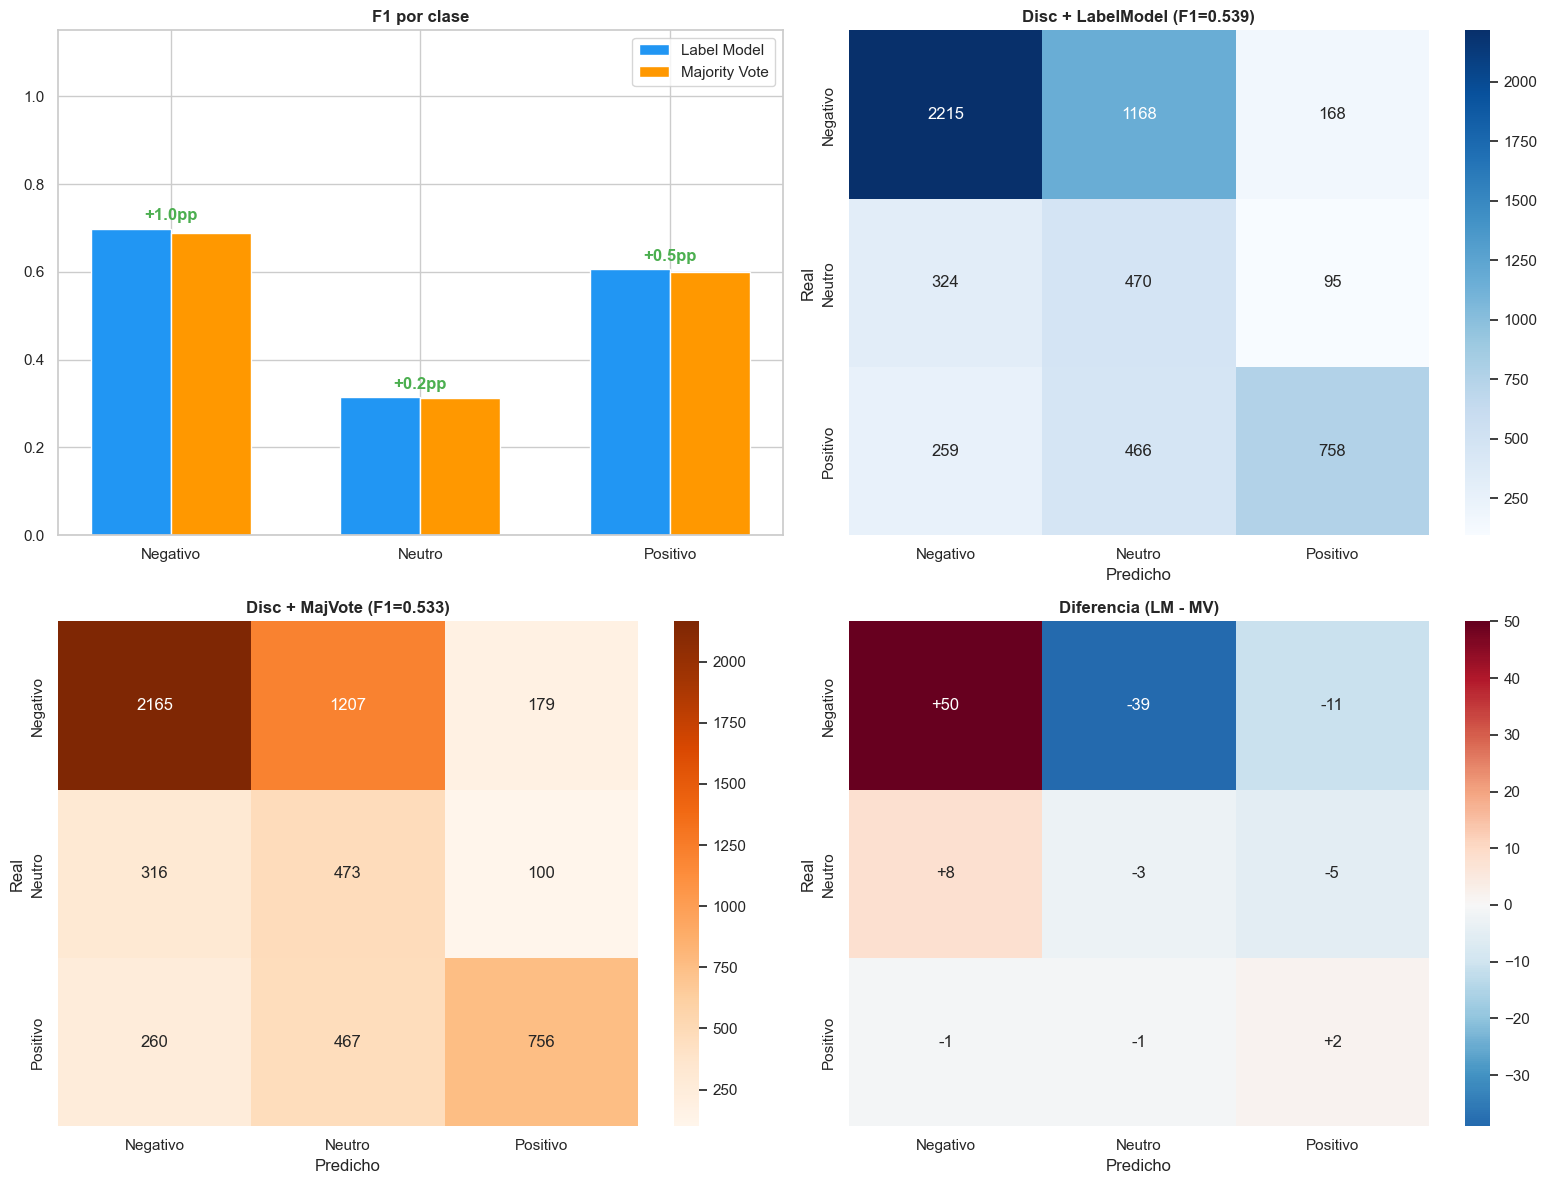

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. F1 por clase
x = np.arange(3); w = 0.32
axes[0,0].bar(x-w/2, f1_lm_c, w, label='Label Model', color='#2196F3', edgecolor='white')
axes[0,0].bar(x+w/2, f1_mv_c, w, label='Majority Vote', color='#FF9800', edgecolor='white')
for i,(v1,v2) in enumerate(zip(f1_lm_c, f1_mv_c)):
    d = (v1-v2)*100; c = '#4CAF50' if d>0 else '#F44336'
    axes[0,0].annotate(f'{d:+.1f}pp', xy=(i, max(v1,v2)+0.02), ha='center', fontweight='bold', color=c)
axes[0,0].set_xticks(x); axes[0,0].set_xticklabels(LABEL_NAMES)
axes[0,0].set_title('F1 por clase', fontweight='bold'); axes[0,0].legend(); axes[0,0].set_ylim(0,1.15)

# 2-3. Confusion matrices
cm_lm = confusion_matrix(y_true, preds_disc_lm)
cm_mv = confusion_matrix(y_true, preds_disc_mv)
sns.heatmap(cm_lm, annot=True, fmt='d', cmap='Blues', xticklabels=LABEL_NAMES, yticklabels=LABEL_NAMES, ax=axes[0,1])
axes[0,1].set_title(f'Disc + LabelModel (F1={f1_lm:.3f})', fontweight='bold')
axes[0,1].set_xlabel('Predicho'); axes[0,1].set_ylabel('Real')

sns.heatmap(cm_mv, annot=True, fmt='d', cmap='Oranges', xticklabels=LABEL_NAMES, yticklabels=LABEL_NAMES, ax=axes[1,0])
axes[1,0].set_title(f'Disc + MajVote (F1={f1_mv:.3f})', fontweight='bold')
axes[1,0].set_xlabel('Predicho'); axes[1,0].set_ylabel('Real')

# 4. Diff heatmap
sns.heatmap(cm_lm-cm_mv, annot=True, fmt='+d', cmap='RdBu_r', center=0, xticklabels=LABEL_NAMES, yticklabels=LABEL_NAMES, ax=axes[1,1])
axes[1,1].set_title('Diferencia (LM - MV)', fontweight='bold')
axes[1,1].set_xlabel('Predicho'); axes[1,1].set_ylabel('Real')

plt.tight_layout(); plt.show()

Desacuerdos: 268 (4.5% del test)
  LabelModel acierta:   140 (52%)
  MajorityVote acierta:   91 (34%)
  Ninguno acierta:        37 (14%)


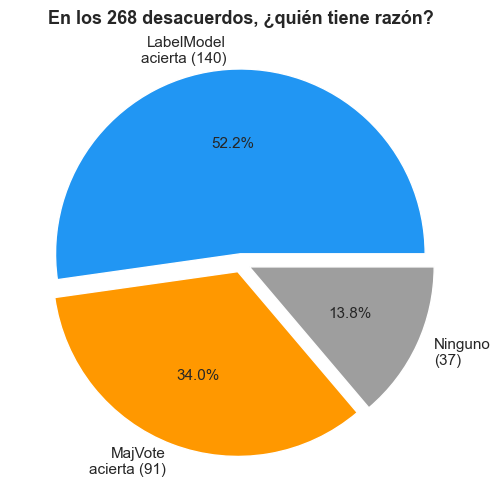

In [11]:
# Análisis de desacuerdos
disagree = preds_disc_lm != preds_disc_mv
n = disagree.sum()
lm_ok = (preds_disc_lm[disagree] == y_true[disagree].values).sum()
mv_ok = (preds_disc_mv[disagree] == y_true[disagree].values).sum()
neither = n - lm_ok - mv_ok

print(f"Desacuerdos: {n} ({n/len(y_true):.1%} del test)")
print(f"  LabelModel acierta:   {lm_ok:3d} ({lm_ok/n:.0%})")
print(f"  MajorityVote acierta:  {mv_ok:3d} ({mv_ok/n:.0%})")
print(f"  Ninguno acierta:       {neither:3d} ({neither/n:.0%})")

fig, ax = plt.subplots(figsize=(6,6))
ax.pie([lm_ok, mv_ok, neither],
       labels=[f'LabelModel\nacierta ({lm_ok})', f'MajVote\nacierta ({mv_ok})', f'Ninguno\n({neither})'],
       colors=['#2196F3','#FF9800','#9E9E9E'], autopct='%1.1f%%', explode=(0.05,0.05,0.05),
       textprops={'fontsize':11})
ax.set_title(f'En los {n} desacuerdos, ¿quién tiene razón?', fontweight='bold', fontsize=13)
plt.show()

---
# Conclusión

Con **32 LFs** de calidad heterogénea, el **Label Model supera al Majority Vote**:

- **+0.57pp de F1 macro** global
- **Gana en las 3 clases** (Negativo, Neutro, Positivo)
- En los desacuerdos, **LM acierta el 52% vs MV el 34%**

### ¿Por qué?

1. **Ponderación inteligente**: el LM asigna pesos distintos a cada LF según su precisión estimada
2. **Modelado de correlaciones**: LFs redundantes (ej: `n_harsh` y `n_appearance`) no sobre-cuentan
3. **Resolución de conflictos**: cuando LFs de NEG y NEUTRO conflictan, el LM usa los pesos para decidir mejor

### ¿Cuándo MV es suficiente?
Cuando tenés pocas LFs, todas de calidad similar, sin correlaciones. En ese caso, la ponderación del LM no aporta.